In [18]:
import numpy as np
import matplotlib.pyplot as plt 

from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [19]:
#Escalamos los valores de pixeles
X_train = X_train/255
X_test = X_test/255

In [20]:
from tensorflow.keras.utils import to_categorical
y_train_cod = to_categorical(y_train, num_classes=10)
y_test_cod = to_categorical(y_test, num_classes=10)

In [21]:
from keras.models import Sequential
modelo = Sequential(name="numeros")

In [22]:
#Convolución
from keras.layers import Conv2D, MaxPool2D, AvgPool2D, Flatten, Dense, Dropout

#Añade una convolución
modelo.add(Conv2D(
    32, #Kernels
    3, #tamaño del kernel, que son 3x3
    input_shape=(28,28,1),
    activation="relu",
    name="convolucion_1"
))

#Añadimos una de pooling
modelo.add(MaxPool2D(name="Pooling", pool_size=(3,3)))#Por defecto es 2x2, pero he puesto 3x3. Coge maximo

modelo.add(Flatten())



c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
from keras.layers import Dense
modelo.add(Dense(1000, activation="relu"))
modelo.add(Dropout(0.1))
modelo.add(Dense(10, activation="softmax"))


In [24]:
modelo.compile(
    loss='categorical_crossentropy',
    optimizer='adam', #probar otros optimizadores
    metrics=['accuracy']
    )

# reshape del dataset como si tuviese un canal (blanco y negro)
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
#entrenamos
h = modelo.fit(
    X_train, y_train_cod,
    epochs=4,
    #si no se especifica bach_size es 32 por defecto
    verbose=True
)

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9593 - loss: 0.1307
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9851 - loss: 0.0465
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9906 - loss: 0.0303
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9932 - loss: 0.0202


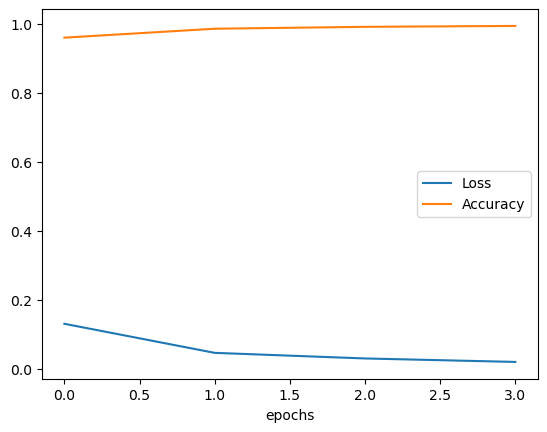

In [25]:
#dibujamos el entrenamiento
import matplotlib.pyplot as plt 
accuracy = h.history['accuracy']
loss = h.history['loss']
n_epochs = len(loss)
plt.plot(range(0, n_epochs), loss, label='Loss')
plt.plot(range(0, n_epochs), accuracy, label="Accuracy")

plt.xlabel('epochs')
plt.legend()

In [26]:
test_loss, test_acc = modelo.evaluate(X_test, y_test_cod)
print("Test loss", test_loss)
print("Test accuracy", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9875 - loss: 0.0377
Test loss 0.037706609815359116
Test accuracy 0.987500011920929


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


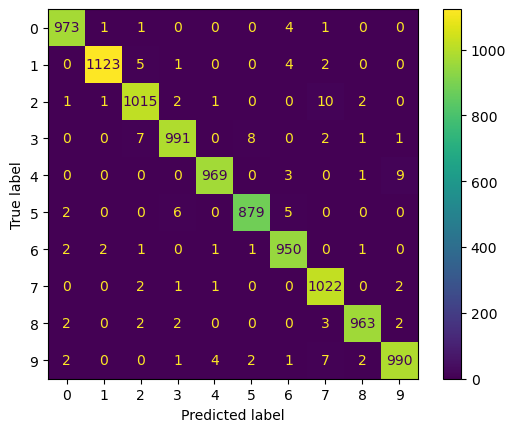

In [27]:
#Vemos la matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = modelo.predict(X_test)
y_pred = [np.argmax(y) for y in y_pred]
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import ConfusionMatrixDisplay
mcd = ConfusionMatrixDisplay(cm)
mcd.plot()

In [28]:
#Vamos a guardar el modelo: podemos usar el módulo Pickle o model.save
modelo.save('mnist_conv.keras')